In [2]:
import os
print(os.getcwd())

C:\Users\hp\Desktop\sentiment-project


In [3]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'output', 'untitled', 'Untitled.ipynb']


In [4]:
print(os.listdir())

['.ipynb_checkpoints', 'output', 'untitled', 'Untitled.ipynb']


In [5]:
import shutil, os

# Check if files exist in Downloads
downloads = r'C:\Users\hp\Downloads'
print(os.listdir(downloads))

['10th marksheet-compressed.pdf', '12th class admit card_11zon.pdf', '12th marksheet_11zon.pdf', '12th migration certificate_11zon.pdf', '12th school marksheet_11zon (1).pdf', '12th school marksheet_11zon.pdf', '12th tc_11zon.pdf', '18LEH101J Nov 2019.pdf', '21LEH101T Jan 2023.pdf', '21LEH101T May 2023.pdf', '3rd sem.pdf', 'aaop', 'aaop.docx', 'aaop.pdf', 'Abstract.docx', 'Abstract.pdf', 'Activity based Learning Models.docx', 'ADARSH PUBLIC SCHOOL.docx', 'Agro bot SPCM.pdf', 'Agro bot.docx', 'Agro bot.pdf', 'AIFundamentalsFoundationsforUnderstandingAI_Badge20260325-31-pbtrxv.pdf', 'AIFundamentalsFoundationsforUnderstandingAI_Badge20260408-31-a1p89r.pdf', 'AI_Enabled_Surveillance_with_Memory_Optimization.docx', 'AI_Surveillance_Expanded_IEEE.tex', 'ALU.pdf', 'Anti ragging affidavit_11zon.pdf', 'Antigravity.exe', 'AntiraggingAffidavitForm.pdf', 'aoop assignment.pdf', 'AOOP student fees management report.pdf', 'archi kl.png', 'architecture_overview.png', 'archive', 'archive.zip', 'assignm

In [6]:
import shutil, os

# Search for the CSV files on Desktop
desktop = r'C:\Users\hp\Desktop'
for root, dirs, files in os.walk(desktop):
    for file in files:
        if 'twitter' in file.lower():
            print(os.path.join(root, file))

In [7]:
import shutil, os

# Search for the CSV files on Desktop
desktop = r'C:\Users\hp\Desktop'
for root, dirs, files in os.walk(desktop):
    for file in files:
        if 'twitter' in file.lower():
            print(os.path.join(root, file))

In [8]:
import os

for root, dirs, files in os.walk(r'C:\Users\hp'):
    for file in files:
        if 'twitter_training' in file.lower():
            print(os.path.join(root, file))

C:\Users\hp\Downloads\archive\twitter_training.csv
C:\Users\hp\OneDrive\Desktop\sentiment-project\twitter_training.csv
C:\Users\hp\OneDrive\Pictures\Screenshots\hadoop\assignment 2\twitter_training.csv


In [9]:
import shutil

# Copy from OneDrive to local project folder
src_train = r'C:\Users\hp\OneDrive\Desktop\sentiment-project\twitter_training.csv'
src_val = r'C:\Users\hp\OneDrive\Desktop\sentiment-project\twitter_validation.csv'
dst = r'C:\Users\hp\Desktop\sentiment-project'

shutil.copy(src_train, dst)
shutil.copy(src_val, dst)

print("Files copied successfully!")
print(os.listdir(dst))

Files copied successfully!
['.ipynb_checkpoints', 'output', 'twitter_training.csv', 'twitter_validation.csv', 'untitled', 'Untitled.ipynb']


In [10]:
import pandas as pd

df = pd.read_csv('twitter_training.csv', header=None)
df.columns = ['id', 'entity', 'sentiment', 'text']
df = df.dropna()
print(df.shape)
df.head()

(73996, 4)


,id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [11]:
df.isnull().sum()

id           0
entity       0
sentiment    0
text         0
dtype: int64

Matplotlib is building the font cache; this may take a moment.


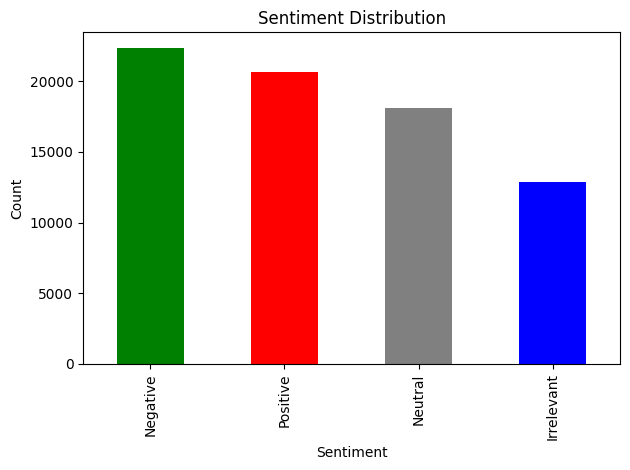

In [12]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'gray', 'blue'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('output/chart1_sentiment.png')
plt.show()

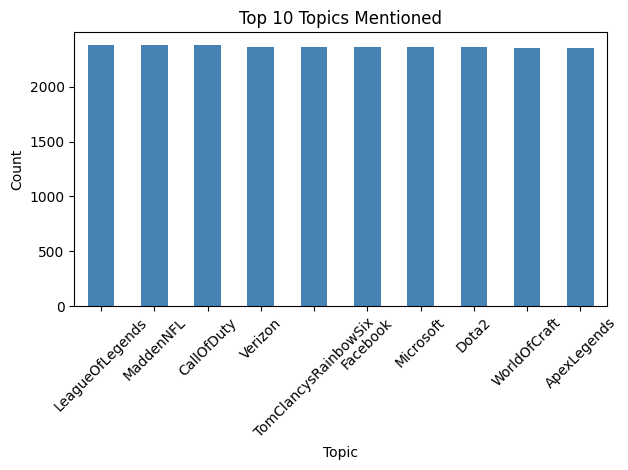

In [13]:
df['entity'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Topics Mentioned')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('output/chart2_topics.png')
plt.show()

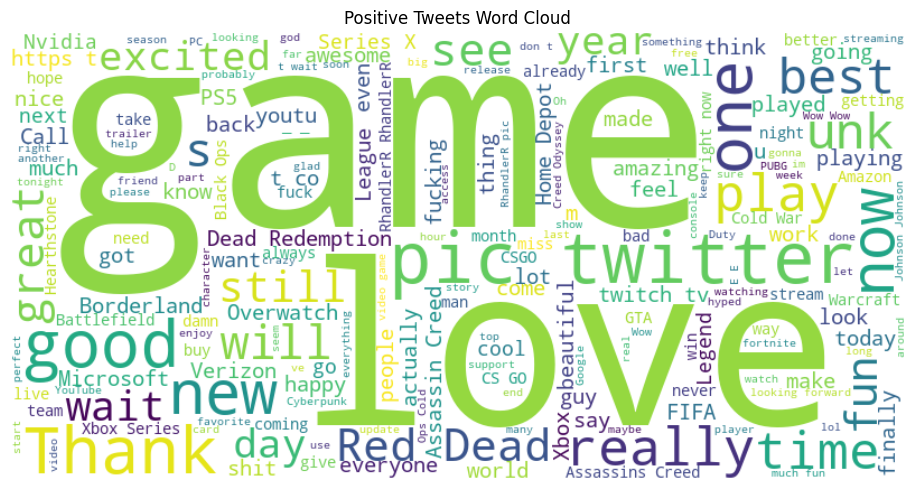

In [14]:
from wordcloud import WordCloud

positive_text = ' '.join(df[df['sentiment'] == 'Positive']['text'].astype(str))

wc = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Tweets Word Cloud')
plt.tight_layout()
plt.savefig('output/chart3_wordcloud.png')
plt.show()